# Week 2 — Predicting EU Developer Salaries with ML

**Author:** Pavethran Muthukumaran · [linkedin.com/in/pavethran-m](https://www.linkedin.com/in/pavethran-m/)
**Dataset:** Stack Overflow Annual Developer Survey 2025
**Scope:** DACH region (Germany, Netherlands, Austria, Switzerland), professional developers only
**Goal:** Predict annual salary (USD) from skills, experience, education, company size. Use SHAP to see what features matter.

Three models in escalating complexity: Linear Regression → Random Forest → XGBoost.

This is Week 2 of an 8-week public sprint: github.com/pavethran/data-science-portfolio


In [3]:
# Colab setup: install SHAP + download the Stack Overflow 2025 CSV
!pip install -q shap
!wget -q -O so_survey_2025.csv "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv"
import os; print("CSV size (MB):", round(os.path.getsize("so_survey_2025.csv")/1e6, 1))

CSV size (MB): 140.9


## 1. Imports & settings


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import shap
import joblib

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Versions:')
print(f'  pandas       {pd.__version__}')
print(f'  numpy        {np.__version__}')
import sklearn; print(f'  scikit-learn {sklearn.__version__}')
print(f'  xgboost      {xgb.__version__}')
print(f'  shap         {shap.__version__}')

Versions:
  pandas       2.2.2
  numpy        2.0.2
  scikit-learn 1.6.1
  xgboost      3.2.0
  shap         0.51.0


## 2. Load the data

Place `so_survey_2025.csv` (the file you downloaded from survey.stackoverflow.co for Week 1) in the same folder as this notebook. If it's elsewhere, update `CSV_PATH`.


In [5]:
CSV_PATH = 'so_survey_2025.csv'   # change if needed
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df[['ResponseId', 'Country', 'MainBranch', 'ConvertedCompYearly']].head()

Loaded 49,191 rows × 172 columns


,ResponseId,Country,MainBranch,ConvertedCompYearly
0,1,Ukraine,I am a developer by profession,61256.0
1,2,Netherlands,I am a developer by profession,104413.0
2,3,Ukraine,I am a developer by profession,53061.0
3,4,Ukraine,I am a developer by profession,36197.0
4,5,Ukraine,I am a developer by profession,60000.0


## 3. Filter to DACH professional developers

Why DACH? Because that's where Pavethran is job-hunting. Same data, narrower lens — strong recruiter angle.


In [6]:
DACH = ['Germany', 'Netherlands', 'Austria', 'Switzerland']

# Coerce salary to numeric (some rows have it as string / NA)
df['ConvertedCompYearly_num'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

mask = (
    df['Country'].isin(DACH) &
    (df['MainBranch'] == 'I am a developer by profession') &
    df['ConvertedCompYearly_num'].notna() &
    df['ConvertedCompYearly_num'].between(20_000, 300_000)   # remove joke values
)
data = df.loc[mask].copy().reset_index(drop=True)
print(f'Rows after filter: {len(data):,}')
print()
print('By country:')
print(data['Country'].value_counts())

Rows after filter: 2,696

By country:
Country
Germany        1658
Netherlands     503
Switzerland     314
Austria         221
Name: count, dtype: int64


## 4. Quick EDA on salary


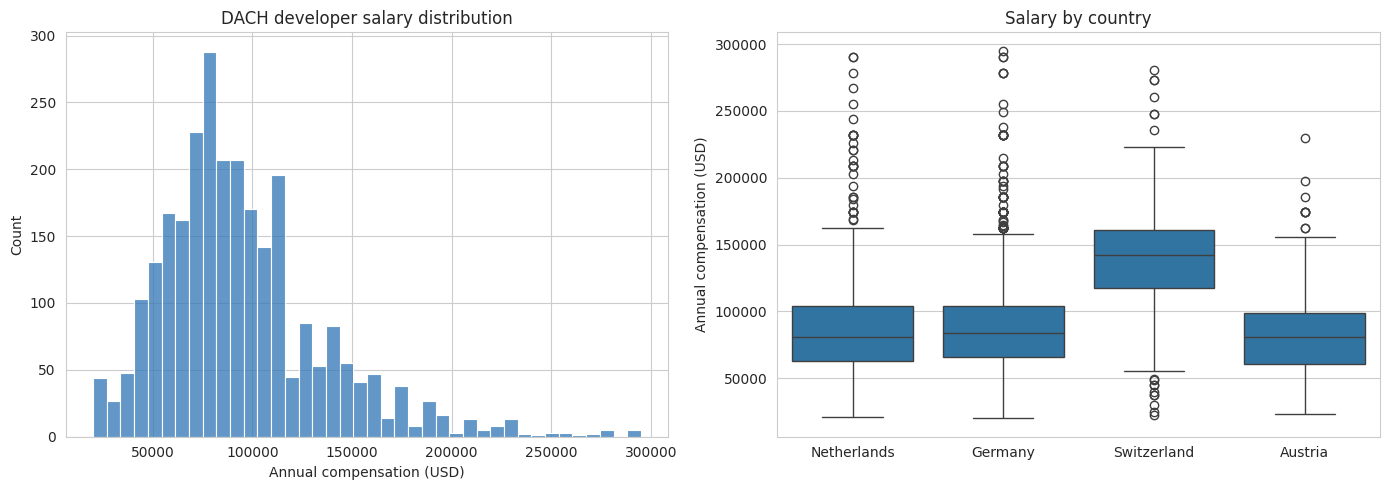

Summary statistics:
             count    median      mean
Country                               
Austria        221   81210.0   83363.0
Germany       1658   83531.0   88736.0
Netherlands    503   81210.0   90639.0
Switzerland    314  141972.0  140483.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sns.histplot(data['ConvertedCompYearly_num'], bins=40, ax=axes[0], color='#2E75B6')
axes[0].set_title('DACH developer salary distribution')
axes[0].set_xlabel('Annual compensation (USD)')

# By country
sns.boxplot(data=data, x='Country', y='ConvertedCompYearly_num', ax=axes[1])
axes[1].set_title('Salary by country')
axes[1].set_xlabel('')
axes[1].set_ylabel('Annual compensation (USD)')

plt.tight_layout()
plt.show()

print('Summary statistics:')
print(data.groupby('Country')['ConvertedCompYearly_num'].agg(['count', 'median', 'mean']).round(0))

## 5. Feature engineering

Build the feature matrix `X` and target `y`. Each block below is one feature family.


In [8]:
# Patch: 2025 SO survey renamed 'YearsCodePro' to 'WorkExp'
if 'YearsCodePro' not in data.columns:
    data['YearsCodePro'] = data['WorkExp']
    print('Patch applied. YearsCodePro present:', 'YearsCodePro' in data.columns)

Patch applied. YearsCodePro present: True


In [9]:
def to_numeric_years(x):
    """Convert 'Less than 1 year', 'More than 50 years', '12' etc. to a float."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.startswith('Less than'):
        return 0.5
    if s.startswith('More than'):
        return 51.0
    try:
        return float(s)
    except ValueError:
        return np.nan

data['YearsCodePro_num'] = data['YearsCodePro'].apply(to_numeric_years)
data['YearsCode_num']    = data['YearsCode'].apply(to_numeric_years)

# Age — map bucket to midpoint
age_map = {
    'Under 18 years old': 17, '18-24 years old': 21, '25-34 years old': 29,
    '35-44 years old': 39, '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 67, 'Prefer not to say': np.nan,
}
data['Age_num'] = data['Age'].map(age_map)

# Education — ordinal
edu_map = {
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6,
    'Other doctoral degree (Ph.D., Ed.D., etc.)': 6,
    'Something else': np.nan,
}
data['EdLevel_ord'] = data['EdLevel'].map(edu_map)

# Org size — ordinal
org_map = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    '2 to 9 employees': 2,
    '10 to 19 employees': 3,
    '20 to 99 employees': 4,
    '100 to 499 employees': 5,
    '500 to 999 employees': 6,
    '1,000 to 4,999 employees': 7,
    '5,000 to 9,999 employees': 8,
    '10,000 or more employees': 9,
    "I don't know": np.nan,
}
data['OrgSize_ord'] = data['OrgSize'].map(org_map)

print('Sample of engineered features:')
data[['YearsCodePro_num', 'Age_num', 'EdLevel_ord', 'OrgSize_ord']].head()

Sample of engineered features:


,YearsCodePro_num,Age_num,EdLevel_ord,OrgSize_ord
0,2.0,29.0,3.0,6.0
1,10.0,29.0,NaN,7.0
2,6.0,29.0,NaN,7.0
3,10.0,39.0,NaN,NaN
4,15.0,39.0,NaN,5.0


In [10]:
# Multi-hot encoding for top 12 languages
TOP_LANGS = ['Python', 'SQL', 'JavaScript', 'TypeScript', 'Java', 'C#',
             'Go', 'R', 'Rust', 'C++', 'Bash/Shell', 'Kotlin']

def lang_list(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

data['Lang_list'] = data['LanguageHaveWorkedWith'].apply(lang_list)
lang_cols = ['lang_' + l.replace('/', '_').replace('+', 'p').replace('#', 'sharp') for l in TOP_LANGS]
for col, lang in zip(lang_cols, TOP_LANGS):
    data[col] = data['Lang_list'].apply(lambda lst: 1 if lang in lst else 0)

print('Top languages in DACH sample:')
print(data[lang_cols].sum().sort_values(ascending=False))

Top languages in DACH sample:
lang_JavaScript    1684
lang_SQL           1512
lang_Python        1404
lang_TypeScript    1313
lang_Java           851
lang_Csharp         725
lang_Cpp            567
lang_Go             462
lang_Rust           428
lang_Kotlin         388
lang_R               72
lang_Bash_Shell       0
dtype: int64


In [11]:
# Country one-hot (4 dummies)
country_dummies = pd.get_dummies(data['Country'], prefix='country').astype(int)

# Final feature matrix
feature_cols = ['YearsCodePro_num', 'YearsCode_num', 'Age_num',
                'EdLevel_ord', 'OrgSize_ord'] + lang_cols
X = pd.concat([data[feature_cols].reset_index(drop=True),
               country_dummies.reset_index(drop=True)], axis=1)
y = data['ConvertedCompYearly_num'].reset_index(drop=True)

# Impute numeric NaNs with median
X = X.fillna(X.median(numeric_only=True))

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print()
print('Feature columns:')
print(list(X.columns))

X shape: (2696, 21)
y shape: (2696,)

Feature columns:
['YearsCodePro_num', 'YearsCode_num', 'Age_num', 'EdLevel_ord', 'OrgSize_ord', 'lang_Python', 'lang_SQL', 'lang_JavaScript', 'lang_TypeScript', 'lang_Java', 'lang_Csharp', 'lang_Go', 'lang_R', 'lang_Rust', 'lang_Cpp', 'lang_Bash_Shell', 'lang_Kotlin', 'country_Austria', 'country_Germany', 'country_Netherlands', 'country_Switzerland']


## 6. Train/test split


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')

Train: 2,156 rows | Test: 540 rows


## 7. Model 1 — Linear regression baseline

Always start with the simplest thing that could work. If complex models can't beat this by a meaningful margin, the complexity is not worth it.


In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

def score(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:22} RMSE ${rmse:>8,.0f}   MAE ${mae:>8,.0f}   R² {r2:6.3f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2}

results = []
results.append(score('Linear Regression', y_test, pred_lr))

Linear Regression      RMSE $  37,204   MAE $  25,161   R²  0.287


## 8. Model 2 — Random Forest


In [14]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results.append(score('Random Forest', y_test, pred_rf))

Random Forest          RMSE $  36,354   MAE $  24,152   R²  0.319


## 9. Model 3 — XGBoost


In [15]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1,
    eval_metric='rmse',
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
pred_xgb = xgb_model.predict(X_test)
results.append(score('XGBoost', y_test, pred_xgb))

XGBoost                RMSE $  37,119   MAE $  25,236   R²  0.290


## 10. Compare all models


In [16]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Pick the winner by RMSE
winner = results_df.loc[results_df['rmse'].idxmin(), 'model']
print(f'\n🏆 Winner by RMSE: {winner}')

            model         rmse          mae       r2
Linear Regression 37203.569430 25161.201715 0.286931
    Random Forest 36354.483356 24152.255259 0.319108
          XGBoost 37118.712937 25235.754391 0.290180

🏆 Winner by RMSE: Random Forest


## 11. Predicted vs actual — visual sanity check


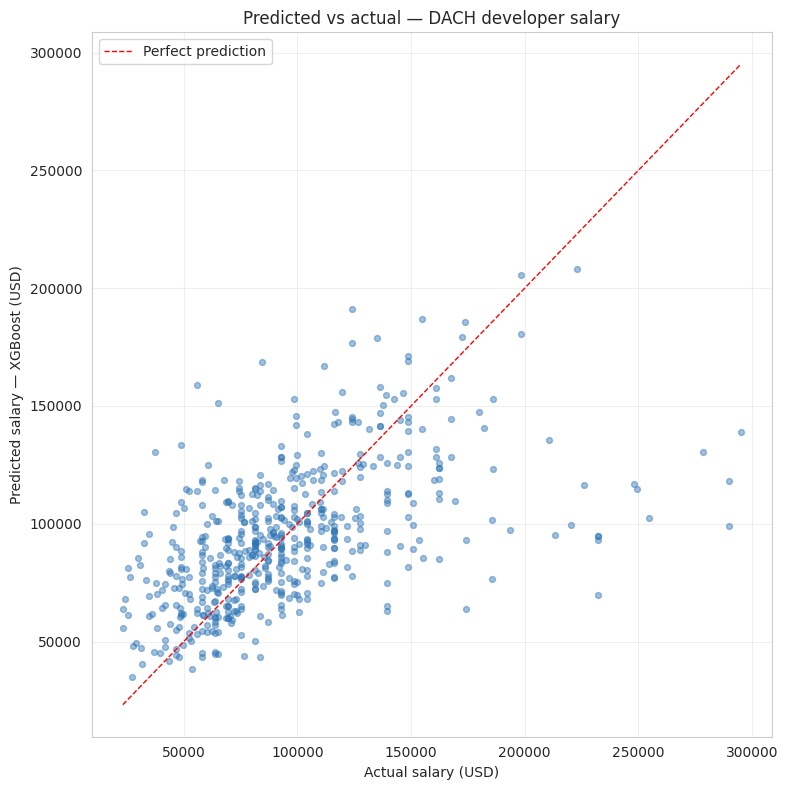

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, pred_xgb, alpha=0.45, s=18, color='#2E75B6')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual salary (USD)')
ax.set_ylabel('Predicted salary — XGBoost (USD)')
ax.set_title('Predicted vs actual — DACH developer salary')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. SHAP feature importance

SHAP tells us how much each feature shifts the model's prediction, averaged across all test examples. Much more honest than `feature_importances_`.


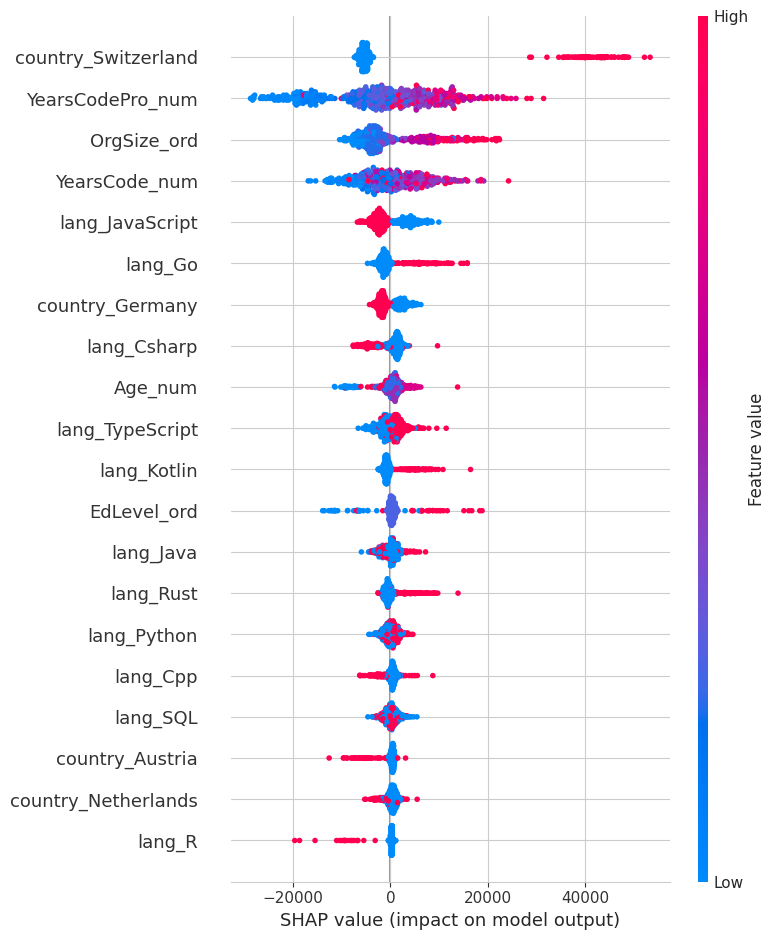

In [18]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# Top 10 features by mean absolute SHAP value
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)
top10 = mean_abs_shap.sort_values(ascending=False).head(10)

print('Top 10 features driving salary predictions (mean |SHAP|, USD):')
for feat, val in top10.items():
    print(f'  {feat:25} ${val:>7,.0f}')

Top 10 features driving salary predictions (mean |SHAP|, USD):
  country_Switzerland       $ 10,229
  YearsCodePro_num          $  9,152
  OrgSize_ord               $  5,835
  YearsCode_num             $  5,032
  lang_JavaScript           $  2,933
  lang_Go                   $  2,181
  country_Germany           $  2,028
  lang_Csharp               $  2,016
  Age_num                   $  1,822
  lang_TypeScript           $  1,669


## 13. Save the trained model + feature names


In [20]:
joblib.dump(xgb_model, 'eu_salary_xgb_model.joblib')
joblib.dump(list(X.columns), 'feature_names.joblib')
results_df.to_csv('model_comparison.csv', index=False)
print('Saved:')
print('  eu_salary_xgb_model.joblib')
print('  feature_names.joblib')
print('  model_comparison.csv')

Saved:
  eu_salary_xgb_model.joblib
  feature_names.joblib
  model_comparison.csv


## 14. Three findings to drop in the LinkedIn post

Run this cell — it auto-writes the 3 bullets using your actual numbers.


In [21]:
best_rmse = results_df.loc[results_df['rmse'].idxmin()]
best_r2 = results_df.loc[results_df['r2'].idxmax()]
delta_lr_xgb = (results_df.iloc[0]['rmse'] - results_df.iloc[-1]['rmse']) / results_df.iloc[0]['rmse'] * 100

top_feat = top10.index[0]
top_feat_value = top10.iloc[0]

print('Finding 1: Best model is {} — RMSE ${:,.0f}, R² {:.2f}.'.format(
    best_rmse['model'], best_rmse['rmse'], best_rmse['r2']
))
print('Finding 2: XGBoost beats Linear Regression by {:.0f}% on RMSE — non-linearities + feature interactions matter.'.format(delta_lr_xgb))
print('Finding 3: The single biggest predictor of salary is {} (mean SHAP impact ${:,.0f}).'.format(top_feat, top_feat_value))

Finding 1: Best model is Random Forest — RMSE $36,354, R² 0.32.
Finding 2: XGBoost beats Linear Regression by 0% on RMSE — non-linearities + feature interactions matter.
Finding 3: The single biggest predictor of salary is country_Switzerland (mean SHAP impact $10,229).


---

## Notes for next time

- The salary range filter ($20k–$300k) drops a few legitimate edge cases. Try widening it and see if XGBoost handles it.
- Adding `RemoteWork`, `Industry`, and `DevType` as features should improve R². Easy next iteration.
- For a Berlin-specific cut, filter `Country == 'Germany'` and inspect whether SHAP importances change.
- If you want a deployable demo, wrap `xgb_model.predict()` in a Streamlit app — see `streamlit.io/cloud` for free hosting.

End of Week 2 notebook. Run all cells, screenshot the SHAP plot, and use the auto-written bullets above as your LinkedIn post.
